In [25]:
# Firstly import all required packages
# enable interactive mode of matplotlib
%matplotlib notebook

# import cv2  # python OpenCV
import os  # 
import numpy as np  # lib for arrays
import datetime
import glob
import pandas as pd

import math as mh  # math package

import matplotlib as mpl  
import matplotlib.pyplot as plt  # namespace for plotting
mpl.rcParams['figure.figsize'] = (9,5)  # change default value of plot size

# matplotlib based package for pretty visualization
import seaborn as sns

import time
import pickle  # package for dump & load data
import warnings

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

from IPython.core.display import display, HTML 
display(HTML("<style>.container { width:85% !important; }</style>"))


## Задачи машинного обучения

__Искусственный интеллект__ - это область информатики, которая занимается разработкой интеллектуальных компьютерных систем, то есть систем, обладающих возможностями, которые мы традиционно связываем с человеческим разумом — понимание языка, обучение, способность рассуждать, решать проблемы и т. д.

<img src="AI.jpg"/>

Определение машинного обучения (T. Mitchell "Machine learning", 1997): "говорят, что компьютерная программа обучается при решении какой-то задачи из класса T, если ее производительность, согласно метрике P, улучшается при накоплении опыта E".

Под опытом E, как правило, понимаются данные, и в зависимости от этого алгоритмы машинного обучения могут быть поделены на тех, что обучаются с учителем и без учителя (supervised & unsupervised learning). 

В задачах обучения без учителя имеется выборка, состоящая из объектов, описываемых набором признаков. В задачах обучения с учителем вдобавок к этому для каждого объекта некоторой выборки, называемой обучающей, известен целевой признак – по сути это то, что хотелось бы прогнозировать для прочих объектов, не из обучающей выборки.

Далее в разных сценариях под T, P, и E подразумеваются совершенно разные вещи. Среди самых популярных **задач T** в машинном обучении ("Deep Learning", Ian Goodfellow, Yoshua Bengio, Aaron Courville, 2016):

* Классификация - отнесение объекта к одной из $k$ категорий. Задача классификации по сути решается формированием функции $f:R^n→ {1, . . . , k}$. Когда $y = f(x)$, модель устанавливает соответствие между входными данными, описываемыми через вектор $x$ к классу с числовым представлением $y$. Существуют другие варианты задачи классфикации, например, когда в качестве результата функции $f$ получается вектор вероятностей принадлжености к каждому классу (http://cs231n.stanford.edu/ ). Примером задач классификации является распознавание объектов, когда входными данными является изображение (представленное как правило набором пикселей определенной яркости), а выходными данными - числовой код, идентифицирующий объект на изображении. Современными задачи распознавания объектов наилучшим образом решаются с применением глубокого обучения (Krizhevsky et al., 2012; Ioﬀe and Szegedy, 2015). 

* Классификация с пропущенными данными - задача классификации, когда во входном векторе $x$ представлен не полностью. Для решения задачи алгоритм определяется одной функцией, при которой входному вектору сопоставляется вектор с категориальными данными на выходе. Когда часть входных данных пропущена, вместо одной функции сопоставления обучающийся алгоритм должен обучиться некоторому набору функций. Каждая из этих функций сопоставляется с различным представлением входного вектора $x$ с учетом пропущенных данных. Задачи подобного рода часто встречаются в задачах определения медицинского диагноза, потому что многие типы медицинских тестов являются дорогостоящими или инвазивными. Единственным способом определения такого большого набора функций является обучение вероятностного распределения относительно всех значимых переменных, а затем решая задачу классификации с помощью частных распределений относительно пропущенных данных. Например, в случае, когда входными данными являются $n$ параметров, мы можем получить все $2^n$ различных функций классификации, необходимых для каждого возможного набора из пропущенных данных, но обучающемуся алгоритму необходимо обучаться только одной функции совместной плотности вероятности. 

* Регрессия - прогнозирование количественного признака объекта на основании прочих его признаков. Для решения этой задачи обученный алгоритм представляет из себя функцию $f:R^n→ R$. Задачи регрессии очень близка к задаче классификации, за исключением представления выходных данных. Примерами задачи регрессии является задача определения страховых выплат, формирования цен, биржевого трейдинга, кредитного скоринга - решения о выдаче/невыдаче кредита.

* Транскрипция - в задачах такого типа системе машинного обучения предлагается проанализировать неструктурированное представление некоторых данных и преобразовать его и в дискретную текстовую форму. Примеры: программа распознавания текста, где на вход поступает изображение текста, а на выходе должен быть набор строковых символов; Google Streer View, вход - изображения улиц, на выходе - названия улиц и номера домов; системы распознавания речи (Amazon Alexa, Yandex Alisa, и др.).

* Машинный перевод - преобразование последовательности символов на одном языке в последовательность символов на другом языке. Обычно такие системы применяются к естественным языкам (Google Translate).

* Структурный вывод - задача, в которой на выходе порождается вектор (или иная структура, содержащая несколько значений), между элементами которого существуют важные связи. Это широкая категория, в которую входят, в частности, задачи транскрипции и перевода. Еще одна задача – грамматический разбор, т. е. преобразование предложения на естественном языке в дерево, описывающее его грамматическую структуру; узлы такого дерева снабжены метками «глагол», «существительное», «наречие» и т. д.Можно также рассмотреть пиксельную сегментацию изображения, когда программа должна отнести каждый пиксель к определенной категории. Например, глубокое обучение можно использовать для аннотирования дорог на аэрофотоснимках . Формат выхода не всегда так точно повторяет формат ввода, как в задачах, сводящихся к аннотированию. Например, в задаче подписывания изображений программе предъявляется изображение, а она выводит его описание в виде предложения на естественном языке. Название «структурный вывод» отражает тот факт, что программа должна вывести несколько тесно связанных между собой значений. Так, слова, порождаемые программой подписывания изображений, должны образовывать допустимое предложение.

* Обнаружение аномалий -  анализ множества событий или объектов и поиск из них нетипичных. Примером может служить обнаружение мошенничества с кредитными картами и системы антифрода. Благодаря моделированию покупательских привычек компания-эмитент кредитных карт может обнаружить аномальное использование карты. Покупки человека, укравшего вашу карту или информацию о ней, зачастую характеризуются не таким распределением вероятности, как ваши. Обнаружив аномальную покупку, компания сможет предотвратить мошенничество, заблокировав счет.

* Синтез и выборка: алгоритм машинного обучения должен генерировать новые примеры, похожие на обучающие данные. Синтез и выборка методами машинного обучения полезны в мультимедийных приложениях, когда генерирование больших объемов данных вручную обходится дорого, скучно или занимает слишком много времени. Например, видеоигры умеют автоматически генерировать текстуры для больших объектов или ландшафтов, не заставляя художника вручную помечать каждый пиксель. В некоторых случаях мы хотим, чтобы процедура выборки или синтеза генерировала определенный выход по заданному входу. Например, в задаче синтеза речи программе передается написанная фраза, а она должна выдать аудиосигнал, содержащий ее же в произнесенном виде. Это разновидность структурного вывода с дополнительной особенностью: для заданного входа не существует единственно правильного выхода, мы специально допускаем большую вариативность выхода, чтобы речевой сигнал звучал естественно и реалистично.

* Подстановка отсутствующих значений. В этом случае алгоритму машинного обучения предъявляется новый пример $x ∈ \mathbb{R}^n$, в котором некоторые элементы $x_i$ отсутствуют. Алгоритм должен спрогнозировать значения отсутствующих элементов. 

* Шумоподавление: алгоритму машинного обучения предъявляется искаженный помехами пример $\widetilde{x} ∈ \mathbb{R}^n$, полученный из чистого примера $x ∈ \mathbb{R}^n$ в результате неизвестного процесса искажения. Алгоритм должен восстановить чистый пример $x$ по искаженному $\widetilde{x}$ или, в более общем случае, вернуть условное распределение вероятности $p(x | \widetilde{x})$.

* Оценка функции вероятности или функции плотности вероятности. В задаче оценки плотности алгоритм должен обучить функцию $p_{model} : \mathbb{R}^n ⟶ \mathbb{R}$, где $p_{model}(x)$ интерпретируется как функция плотности вероятности (если $x$ – непрерывная случайная величина) или как функция вероятности (в дискретном случае) в пространстве, из которого были взяты примеры. Чтобы решить эту задачу хорошо (что это значит, мы точно определим в разделе о мерах качества), алгоритм должен выявить структуру предъявленных данных. Он должен понять, где примеры расположены тесно, а где их появление маловероятно. Для большинства описанных выше задач требуется, чтобы алгоритм хотя бы неявно уловил структуру распределения вероятности. В задаче оценки плотности это распределение должно быть определено явно. В принципе, найденное распределение впоследствии можно использовать для решения других задач. Например, получив распределение вероятности $p(x)$, мы можем воспользоваться им для подстановки отсутствующих значений. Если значение $x_i$ отсутствует, а все остальные значения, множество которых обозначается $x_{–i}$, имеются, то мы знаем, что распределение $x_i$ имеет вид $p(x_i | x_{–i})$. На практике оценка плотности не всегда позволяет решить все сопутствующие задачи, потому что операции, которые нужно выполнить с $p(x)$, требуют непомерно большого объема вычислений.

* Кластеризация – разбиение множества объектов на группы на основании признаков этих объектов так, чтобы внутри групп объекты были похожи между собой, а вне одной группы – менее похожи.

* и др.

__Метрики P__:
* Accuracy (верность) - доля примеров, на которых модель выдаёт правильный результат. Метрика логичная, но на практике не используемая:

$$ Accuracy = \dfrac{TP + TN}{TP + TN + FP + FN}$$
* Precision, recall и $f_{\beta}$-score:

$$precision = \dfrac{TP}{TP + FP}$$

$$recall = \dfrac{TP}{TP + FN}$$

$$f_{\beta} = (1 + \beta^2)\dfrac{precision * recall}{(1 + \beta^2) * precision + recall} $$


Типы признаков:
* бинарный - принимает два значения ({0,1} или {-1, 1} или {мужчина, женщина})
* номинальный - конечное множество (палитра радуги, улицы города)
* порядковый - конечное упорядоченное множество (тяжесть состояния пациента)
* количественный - числовое значение из $\mathbb{R}$ (возраст, температура, вес, расстояние)

Для дальнейшего рассмотрения примера анализа данных воспользуемся датасетом [House Sales in King County, USA](https://www.kaggle.com/datasets).

In [9]:
# импортируем датасет
sales = pd.read_csv(r'./dataset/kc_house_data.csv')

In [10]:
# посмотрим на него 
sales.head(10)

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
5,7237550310,20140512T000000,1225000.0,4,4.50,5420,101930,1.0,0,0,...,11,3890,1530,2001,0,98053,47.6561,-122.005,4760,101930
6,1321400060,20140627T000000,257500.0,3,2.25,1715,6819,2.0,0,0,...,7,1715,0,1995,0,98003,47.3097,-122.327,2238,6819
7,2008000270,20150115T000000,291850.0,3,1.50,1060,9711,1.0,0,0,...,7,1060,0,1963,0,98198,47.4095,-122.315,1650,9711
8,2414600126,20150415T000000,229500.0,3,1.00,1780,7470,1.0,0,0,...,7,1050,730,1960,0,98146,47.5123,-122.337,1780,8113
9,3793500160,20150312T000000,323000.0,3,2.50,1890,6560,2.0,0,0,...,7,1890,0,2003,0,98038,47.3684,-122.031,2390,7570


In [11]:
# названия признаков
print(sales.columns)

Index(['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqft_living15', 'sqft_lot15'],
      dtype='object')


In [12]:
# Проверим наличие NaN значений в датасете
print(sales.isnull().any())

id               False
date             False
price            False
bedrooms         False
bathrooms        False
sqft_living      False
sqft_lot         False
floors           False
waterfront       False
view             False
condition        False
grade            False
sqft_above       False
sqft_basement    False
yr_built         False
yr_renovated     False
zipcode          False
lat              False
long             False
sqft_living15    False
sqft_lot15       False
dtype: bool


In [13]:
# Inspecting type
print(sales.dtypes)

id                 int64
date              object
price            float64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object


In [14]:
# Уберём id и дату из набора данных
sales = sales.drop(['id', 'date'], axis=1)

In [15]:
sales.head(10)

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
5,1225000.0,4,4.50,5420,101930,1.0,0,0,3,11,3890,1530,2001,0,98053,47.6561,-122.005,4760,101930
6,257500.0,3,2.25,1715,6819,2.0,0,0,3,7,1715,0,1995,0,98003,47.3097,-122.327,2238,6819
7,291850.0,3,1.50,1060,9711,1.0,0,0,3,7,1060,0,1963,0,98198,47.4095,-122.315,1650,9711
8,229500.0,3,1.00,1780,7470,1.0,0,0,3,7,1050,730,1960,0,98146,47.5123,-122.337,1780,8113
9,323000.0,3,2.50,1890,6560,2.0,0,0,3,7,1890,0,2003,0,98038,47.3684,-122.031,2390,7570


<IPython.core.display.Javascript object>


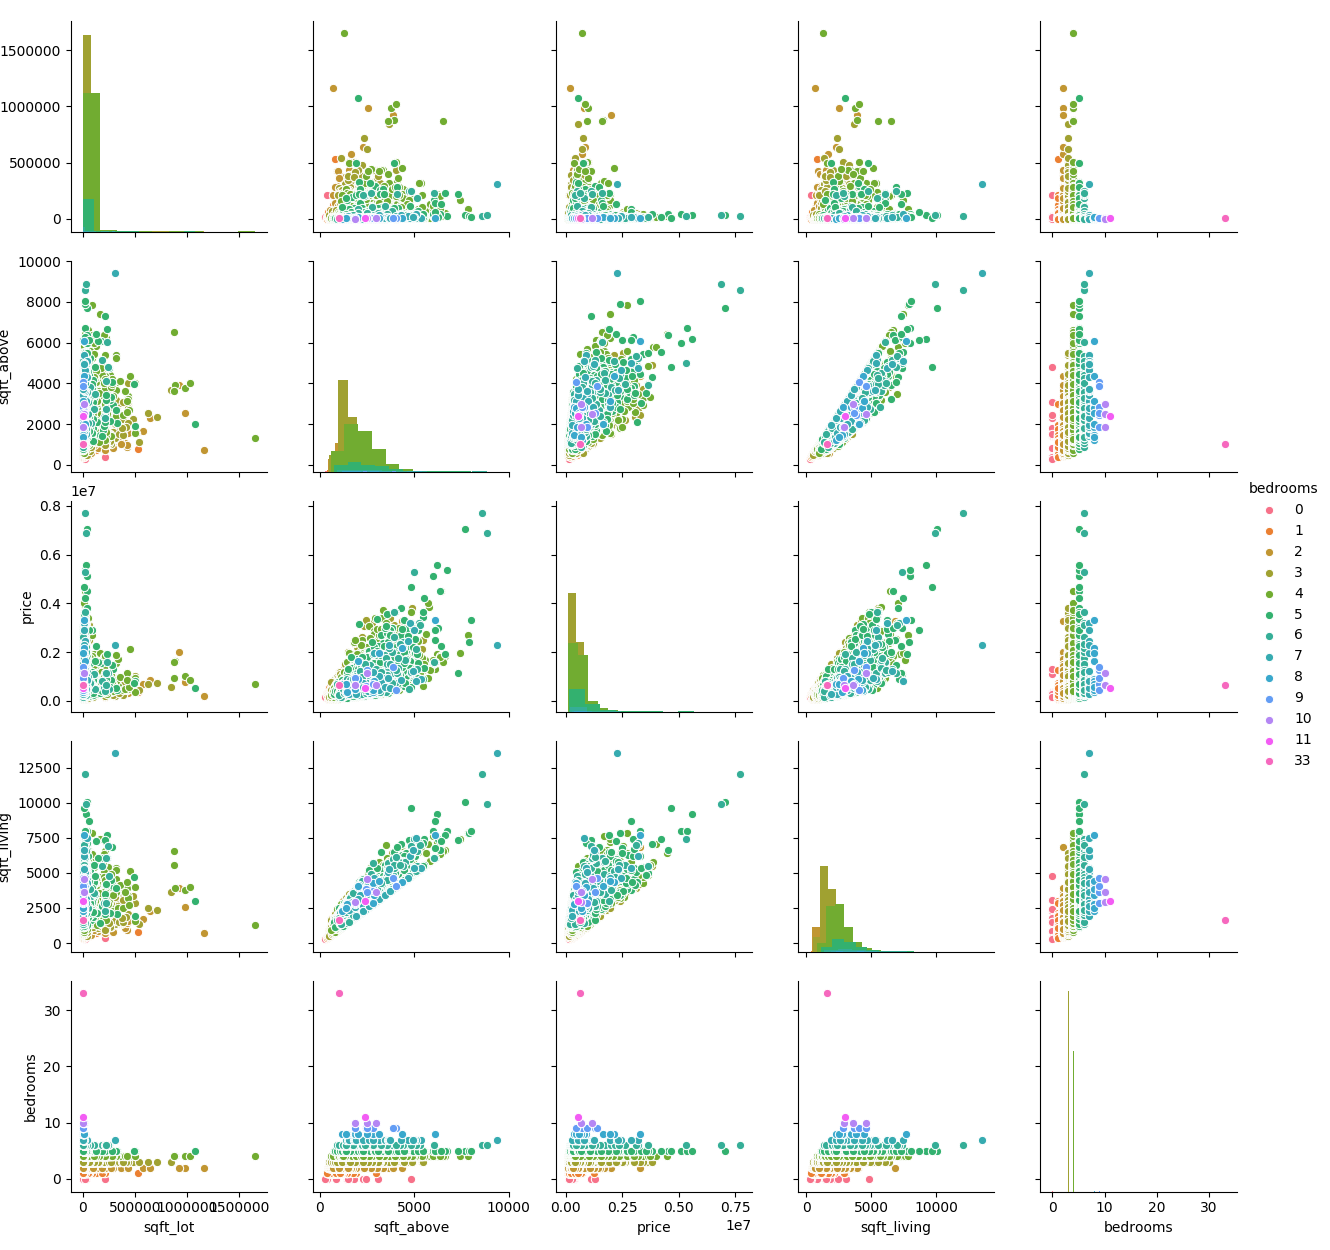

In [28]:
sns.pairplot(sales[['sqft_lot','sqft_above','price','sqft_living', 'bedrooms']], hue='bedrooms', diag_kind='hist')

<IPython.core.display.Javascript object>


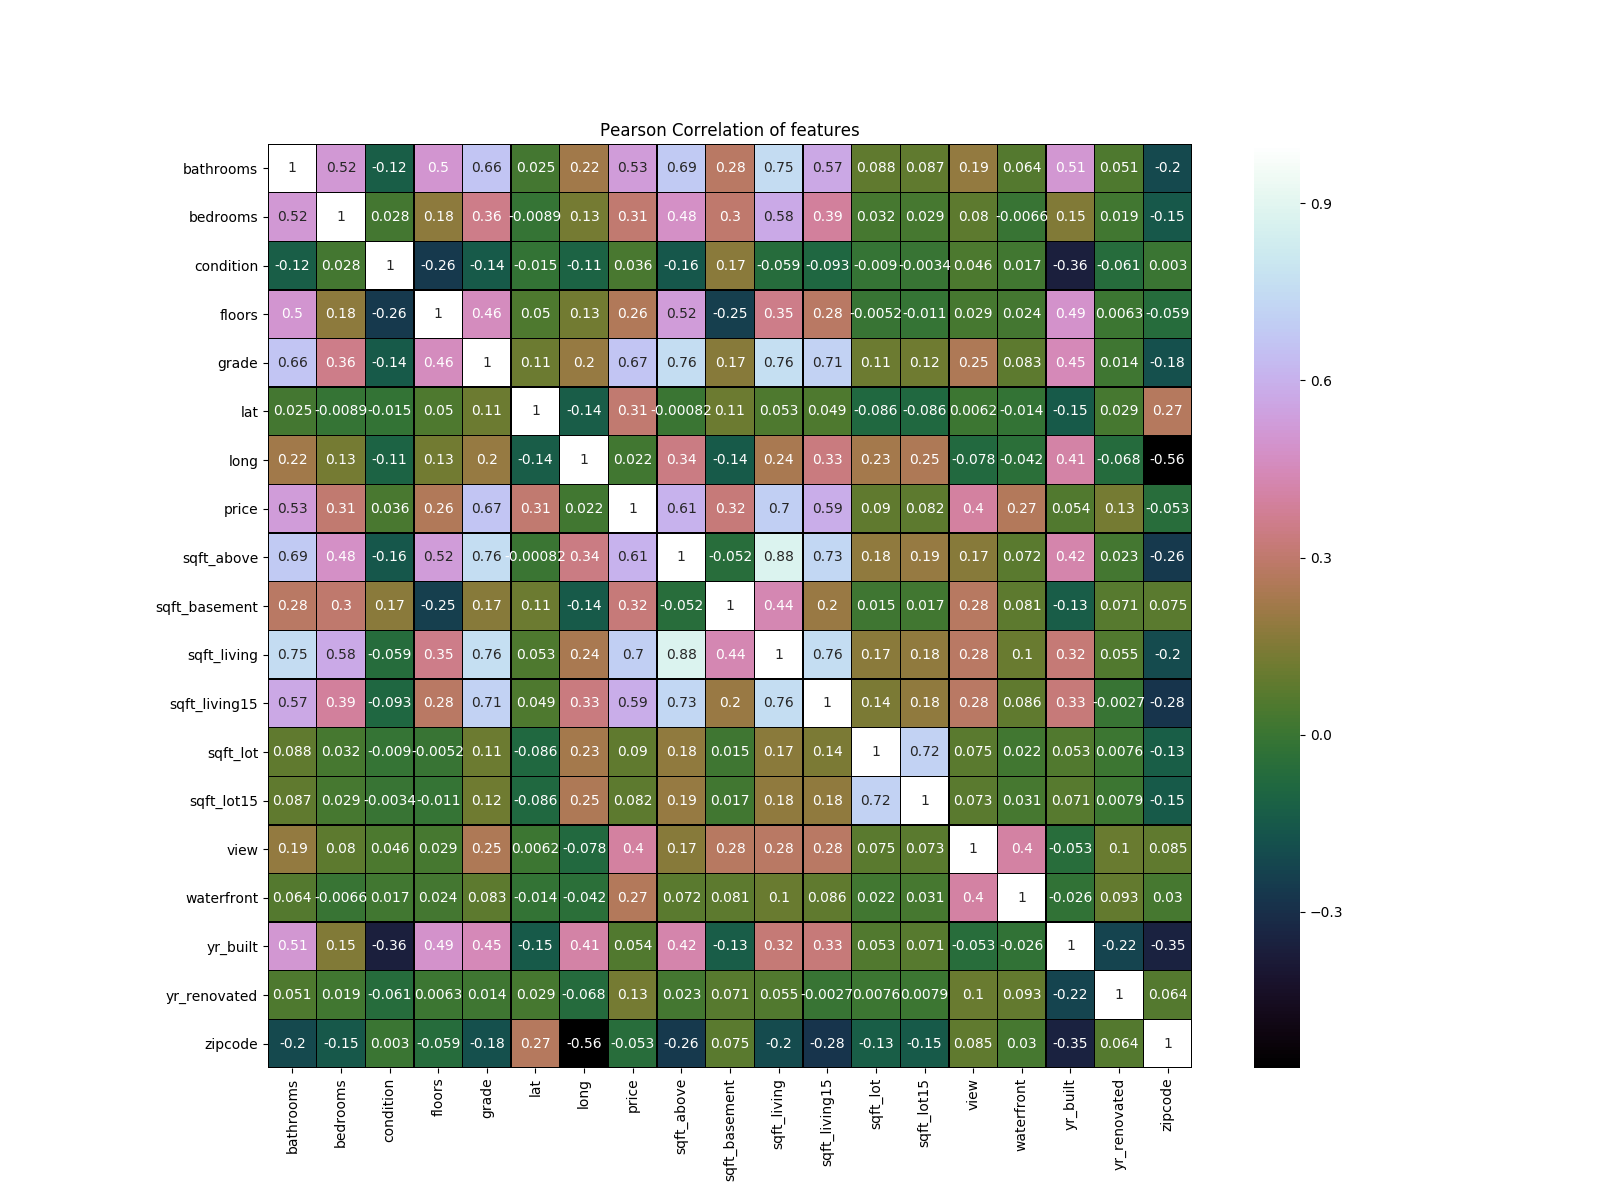

Text(0.5, 1.0, 'Pearson Correlation of features')

In [30]:
str_list = [] # empty list to contain columns with strings (words)
for colname, colvalue in sales.iteritems():
    if type(colvalue[1]) == str:
         str_list.append(colname)
# Get to the numeric columns by inversion            
num_list = sales.columns.difference(str_list) 
# Create Dataframe containing only numerical features
house_num = sales[num_list]
f, ax = plt.subplots(figsize=(16, 12))
plt.title('Pearson Correlation of features')
# Draw the heatmap using seaborn
sns.heatmap(house_num.astype(float).corr(),linewidths=0.25,vmax=1.0, square=True, cmap="cubehelix", linecolor='k', annot=True)

Description of `tips` dataset.

Food servers’ tips in restaurants may be influenced by many factors, including the nature of the restaurant, size of the party, and table locations in the restaurant. Restaurant managers need to know which factors matter when they assign tables to food servers. For the sake of staff morale, they usually want to avoid either the substance or the appearance of unfair treatment of the servers, for whom tips (at least in restaurants in the United States) are a major component of pay. In one restaurant, a food server recorded the following data on all cus- tomers they served during an interval of two and a half months in early 1990. The restaurant, located in a suburban shopping mall, was part of a national chain and served a varied menu. In observance of local law, the restaurant offered to seat in a non-smoking section to patrons who requested it. Each record includes a day and time, and taken together, they show the server’s work schedule.

In [197]:
# use another dataset from seaborn docs for checking boxplot
tips = sns.load_dataset("tips")

In [198]:
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
5,25.29,4.71,Male,No,Sun,Dinner,4
6,8.77,2.00,Male,No,Sun,Dinner,2
7,26.88,3.12,Male,No,Sun,Dinner,4
8,15.04,1.96,Male,No,Sun,Dinner,2
9,14.78,3.23,Male,No,Sun,Dinner,2


<IPython.core.display.Javascript object>


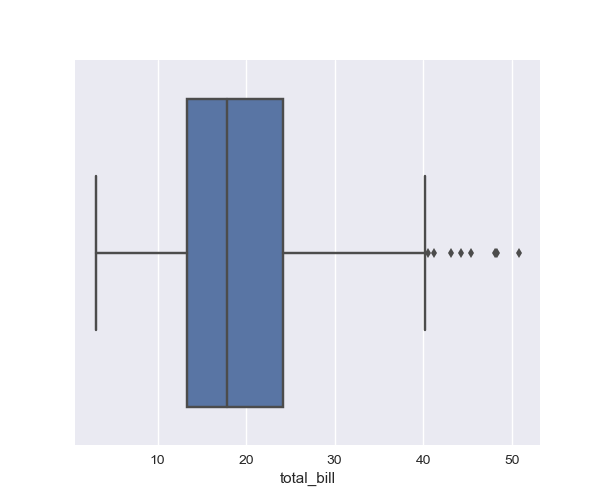

In [199]:
plt.figure()
ax = sns.boxplot(x=tips["total_bill"])

<IPython.core.display.Javascript object>


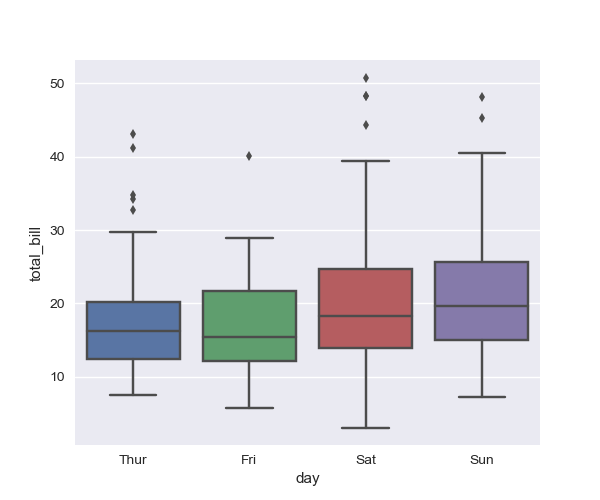

In [195]:
plt.figure()
ax = sns.boxplot(x="day", y="total_bill", data=tips)

<img src="images/boxplot.png"/>

Наглядный пример, как графический анализ может применяться для более сложных данных

https://www.kaggle.com/tsilveira/applying-heatmaps-for-categorical-data-analysis

In [201]:
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
5,25.29,4.71,Male,No,Sun,Dinner,4
6,8.77,2.00,Male,No,Sun,Dinner,2
7,26.88,3.12,Male,No,Sun,Dinner,4
8,15.04,1.96,Male,No,Sun,Dinner,2
9,14.78,3.23,Male,No,Sun,Dinner,2


# Первые шаги в Scikit-Learn

Как быть, если мы хотим подсмотреть на данные, которые представлены в `N` мерном признаковом пространстве, но хочется отразить их на двумерное с сохранением расстояний?

Существует возможность представления данных через **[t-SNE](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html)**. Для корректной работы алгоритма необходимо также выполнить предварительное масштабирование признаков к одинаковому интервалу, что может быть достигнуто с помощью функции **[StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)**.

In [205]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

In [206]:
X = df_iris.drop(['target'], axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [207]:
tsne = TSNE(random_state=17)
tsne_representation = tsne.fit_transform(X_scaled)

In [213]:
df_iris.target.value_counts()

versicolor    50
setosa        50
virginica     50
Name: target, dtype: int64

<IPython.core.display.Javascript object>


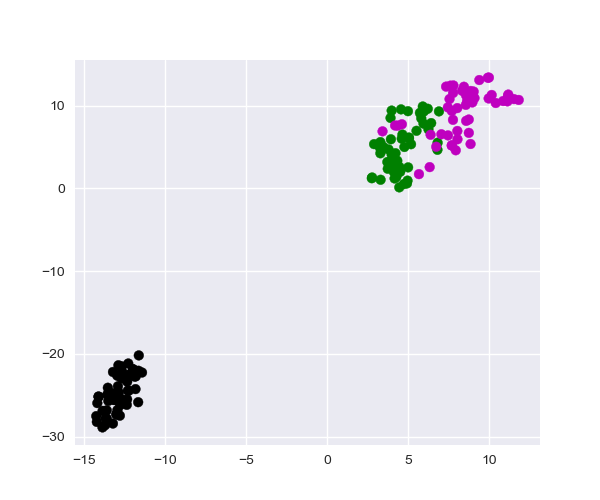

In [215]:
plt.figure()
plt.scatter(tsne_representation[:, 0], 
            tsne_representation[:, 1], 
            c=df_iris['target'].map({'setosa': 'k', 'virginica': 'm', 'versicolor': 'g'}));

Вот пример, как можно поиграться с различными параметрами **[t-SNE](https://distill.pub/2016/misread-tsne/)**.

# <center> Деревья решений </center>
<img src="images/tree.jpeg"/>

__Дерево решений__ – это модель, представляющая собой совокупность правил для принятия решений.

Графически её можно представить в виде древовидной структуры, где моменты принятия решений соответствуют так называемым узлам (_decision  nodes_). В узлах происходит ветвление процесса (_branching_), т.е.  деление его на так называемые ветви (_branches_) в зависимости от сделанного выбора. Конечные (или, что то же самое, терминальные) узлы называют листьями (_leafs, leafnodes_), где каждый лист – это конечный результат последовательного принятия решений.

Построение дерева основано на приросте информации в каждом узле, т.е. уменьшении энтропии Шеннона:

$$ S=-\sum_{i}^{N}{p_i\,log_2 p_i} $$

Уменьшение энтропии при разбиении по признаку _Q_ оценивается с помощью прироста информации (Information Gain - IG):

$$ IG(Q) = S_{0} - \sum_{i=1}^{q}\dfrac{N_i}{N} S_{i} $$

[Официальная документация Scikit-Learn Decision Trees](https://scikit-learn.org/stable/modules/tree.html)

# Overfitting
Сгенерируем функцию синуса на отрезке $[0, 1]$, предварительно добавив к ней шум:

In [187]:
random_seed = 90

In [188]:
np.random.seed(random_seed) # set seed for reproducable data
x_sin = np.linspace(0, 1, 10)  # x values
y_sin = np.sin(x_sin * 2 * np.pi) + np.random.randn(x_sin.size) * 0.3

In [189]:
np.random.seed(random_seed)
x_plot = np.linspace(0, 1, 100000)
y_test = np.sin(x_plot * 2 * np.pi) + np.random.randn(x_plot.size) * 0.3

<IPython.core.display.Javascript object>


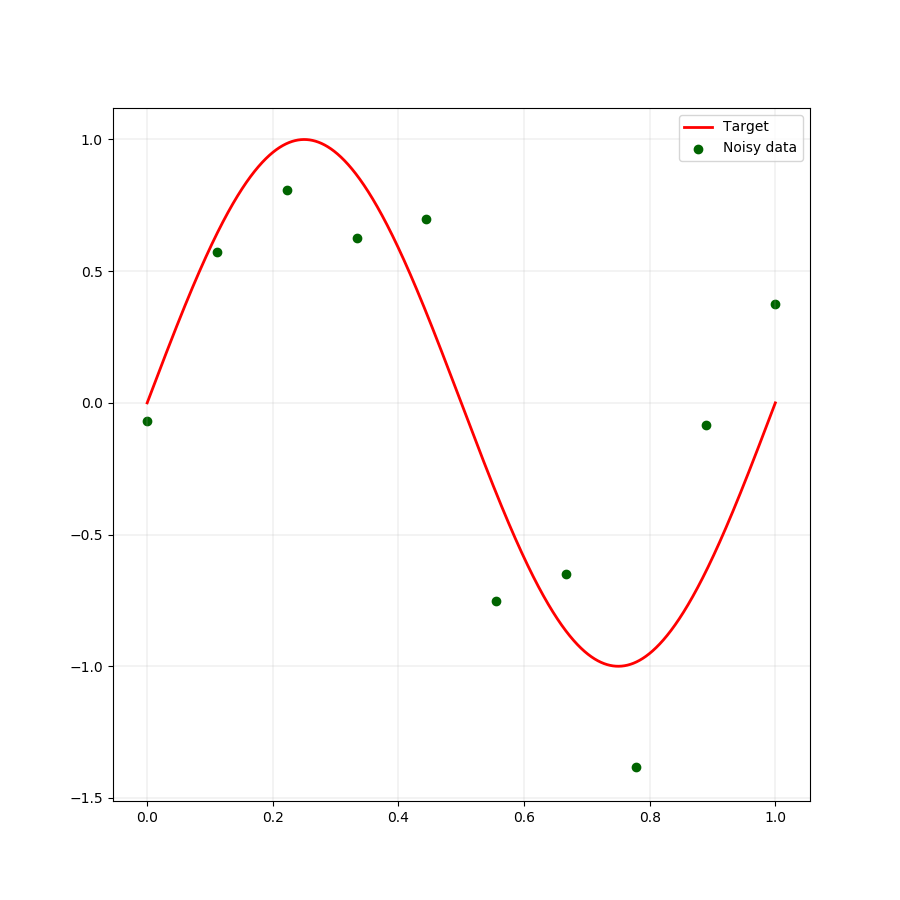

In [190]:
plt.figure(figsize=(9, 9))
plt.plot(x_plot, np.sin(x_plot * 2 * np.pi), color='r', linewidth=2.0)
plt.scatter(x_sin, y_sin, color='darkgreen')
plt.legend(['Target', 'Noisy data'])
plt.grid(linewidth=0.2)

Пусть будем искать представление искомой функции в полиномиальной форме:

$$ y(x, \textbf{w}) = w_0 + w_1\,x + w_2\,x + \dots + w_M\,x^M = \sum_{j=0}^{M} w_j\,x^j,$$
где $ M $ - порядок полинома, $ w_j $ коэффициенты полинома.

Функция $ y(x, \textbf{w}) $ нелинейна относительно $ x^j $, но линейна относительно коэффицентов $ w_j $. Такие модели, в которых обучаемые параметры (коэффициенты в данном случае) называются __линейными__. 

Значения коэффициентов $ w_j $ могут быть получены за счет аппроксимации полиномом исходных данных. Аппроксимая данных полиномом производится согласно уменьшению ошибки аппроксимации $ E $. Такой ошибкой часто выступает квадратичная функция потерь:

$$ E(\textbf{w}) = \dfrac{1}{2} \sum_{n=1}^{N} (y(x_n, \textbf{w}) - t_n)^2, $$ 
где $ N $ - размер данных.

Аппроксимая данных в данном случае будет производиться так, чтобы уменьшить расстояние между каждой точкой из наблюдаемых данных и значением, предсказанным моделью. Существует значение $ w^* $, которое является минимумом функции $ E(\textbf{w}) $. Тогда функция $ y(x, \textbf{w^*}) $ будет удовлетворять условию минимума среднеквадратичной ошибки. 

Когда необходимо сравнить ошибку на данных разного размера, оценивают среднеквадратичное отклонение ошибки:
$$E_{RMS} = \sqrt{\dfrac{2E\textbf(w^*)}{N}}$$

Но какое значение степени полинома $ M $ следует выбрать? Рассмотрим значения полинома $ M = 0, 1, 2, 3, 9 $.

In [191]:
# import sklearn regressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge, LinearRegression

In [207]:
m_values = np.arange(10)
y_m = {'train': {}, 
       'test': {}}
models = {}
for m in m_values:
    poly = PolynomialFeatures(degree=m)
    poly_ = poly.fit_transform(x_sin.reshape(-1, 1))
    x_plot_ = poly.fit_transform(x_plot.reshape(-1, 1))
    lg = LinearRegression()
    lg.fit(poly_, y_sin)
    models[m] = lg
    y_m['test'][m] = lg.predict(x_plot_)
    y_m['train'][m] = lg.predict(poly.fit_transform(x_sin.reshape(-1, 1)))

<IPython.core.display.Javascript object>


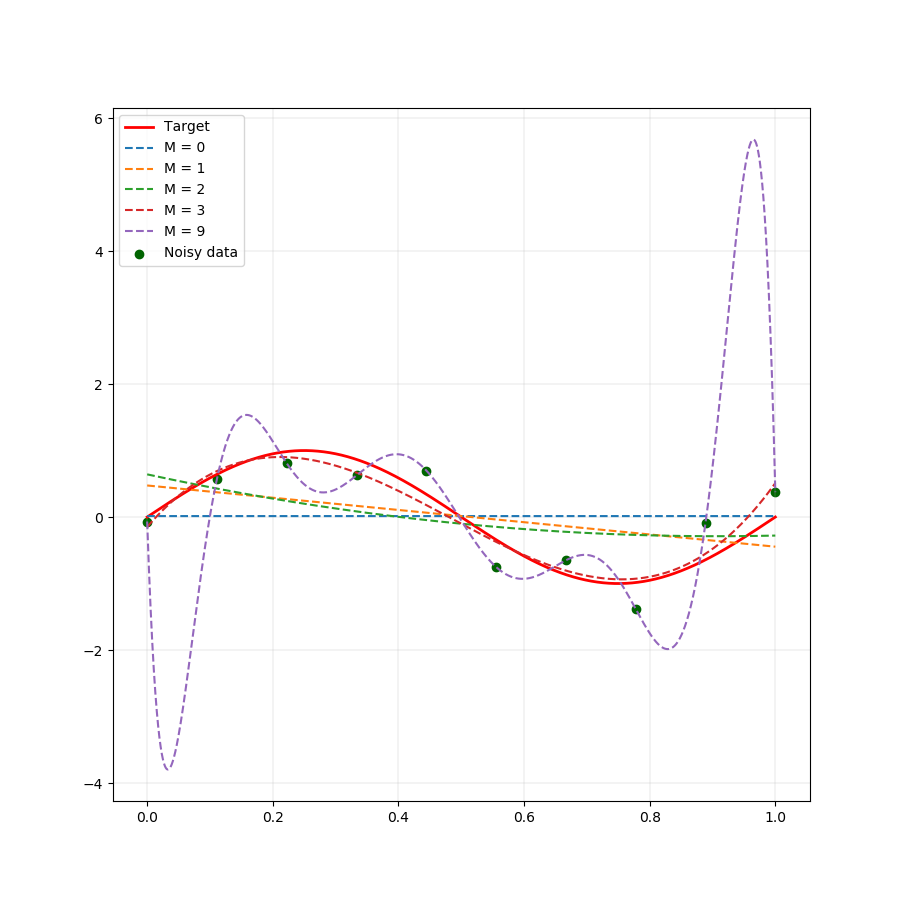

In [208]:
plt.figure(figsize=(9, 9))
plt.plot(x_plot, np.sin(x_plot * 2 * np.pi), color='r', linewidth=2.0)
m_except = list(range(4, 9))

for m in m_values:
    if m not in m_except:
        plt.plot(x_plot, y_m['test'][m], linestyle='--')
plt.scatter(x_sin, y_sin, color='darkgreen')

plt.legend(['Target', *('M = ' + str(i) for i in m_values if i not in m_except), 'Noisy data'])
plt.grid(linewidth=0.2)

Вычислим $E_{RMS}$ для каждого из значений степени полинома в случае обучающей *(x_sin, y_sin)* и тестовой выборки *(x_plot, y_test)*:

In [202]:
# define E_rms function
def e_rms(y_true, y_pred):
    return np.sqrt(np.sum((y_true - y_pred)**2)/y_true.size)

error_rms = {'train': {}, 
             'test': {}}
for m in m_values:
    error_rms['train'][m] = e_rms(y_sin, y_m['train'][m])
    error_rms['test'][m] = e_rms(y_test, y_m['test'][m])

И построим графики значений $ E_{RMS} $ от значения степени полинома для обучающей и тестовой выборок:

<IPython.core.display.Javascript object>


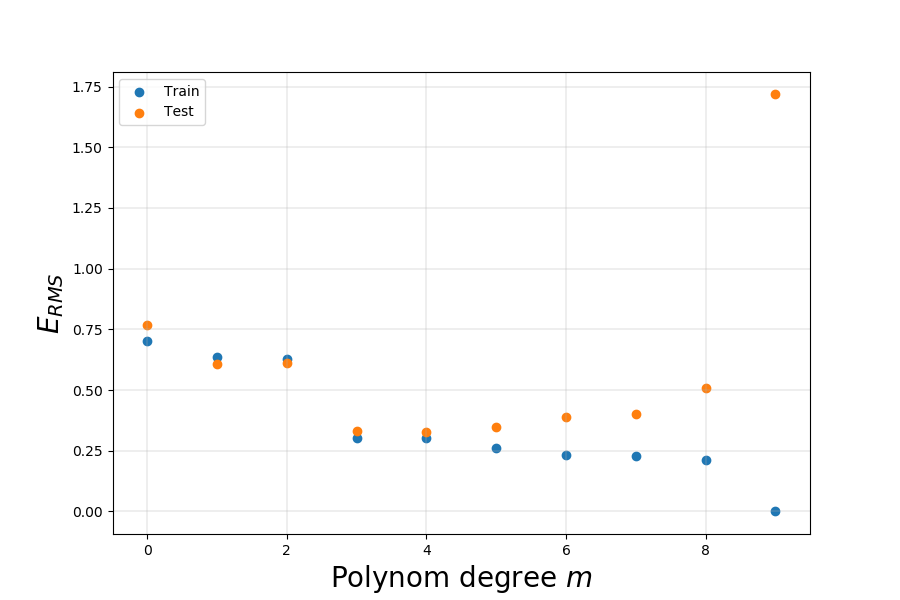

In [204]:
plt.figure(figsize=(9, 6))
plt.scatter(m_values, np.array([v for k, v in error_rms['train'].items()]))
plt.scatter(m_values, np.array([v for k, v in error_rms['test'].items()]))
plt.legend(['Train', 'Test'])
plt.xlabel(r'Polynom degree $ m$', fontsize=20)
plt.ylabel(r'$E_{RMS}$', fontsize=20)
plt.grid(linewidth=0.3)

Сделаем выводы по графику:
* Ошибка на train упала до 0 в случае $ M = 9 $, модель при этом абсолютно точно аппроксимировала данные. Ошибка на тестовой выборке резко возросла.
* Качественную аппроксимацию данных обеспечивают порядки полинома от 3 до 8

Что же происходит с весами полинома при этом? Посмотрим на них:


In [216]:
for m in m_values:
    print('Model with degree M={}'.format(m))
    for n_w, weight in enumerate(models[m].coef_):
        print('w_{} = {:.2f}'.format(n_w, weight), end=' ')
    print()

Model with degree M=0
w_0 = 0.00 
Model with degree M=1
w_0 = 0.00 w_1 = -0.92 
Model with degree M=2
w_0 = 0.00 w_1 = -2.05 w_2 = 1.13 
Model with degree M=3
w_0 = 0.00 w_1 = 10.96 w_2 = -33.16 w_3 = 22.86 
Model with degree M=4
w_0 = 0.00 w_1 = 10.13 w_2 = -28.95 w_3 = 16.12 w_4 = 3.37 
Model with degree M=5
w_0 = 0.00 w_1 = 0.99 w_2 = 47.21 w_3 = -199.17 w_4 = 250.14 w_5 = -98.71 
Model with degree M=6
w_0 = 0.00 w_1 = 13.03 w_2 = -101.34 w_3 = 440.18 w_4 = -985.40 w_5 = 1000.33 w_6 = -366.34 
Model with degree M=7
w_0 = 0.00 w_1 = 6.86 w_2 = 0.43 w_3 = -163.28 w_4 = 720.93 w_5 = -1488.00 w_6 = 1439.45 w_7 = -515.94 
Model with degree M=8
w_0 = 0.00 w_1 = 43.64 w_2 = -741.26 w_3 = 5430.93 w_4 = -20382.90 w_5 = 42448.14 w_6 = -49819.38 w_7 = 30867.01 w_8 = -7845.74 
Model with degree M=9
w_0 = 0.00 w_1 = -274.30 w_2 = 6602.55 w_3 = -60717.41 w_4 = 290373.16 w_5 = -804166.80 w_6 = 1336461.31 w_7 = -1313739.15 w_8 = 703548.74 w_9 = -158087.66 


Значения коэффициентов возрастают с увеличением степени полинома, а модель пытается аппроксимровать шумовые значения. Это явление называется **`overfitting`**.

Обучим модель со степенью полинома 9, но увеличим обучающую выборку до 100 значений:

In [218]:
np.random.seed(random_seed)
x_train = np.linspace(0, 1, 100)
y_train = np.sin(2 * np.pi * x_train) + np.random.randn(x_train.size) * 0.3

Построим график и посмотрим, как обучилась в таком случае модель:

In [219]:
poly = PolynomialFeatures(degree=9)
poly_ = poly.fit_transform(x_train.reshape(-1, 1))
lg = LinearRegression()
lg.fit(poly_, y_train)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None,
         normalize=False)

<IPython.core.display.Javascript object>


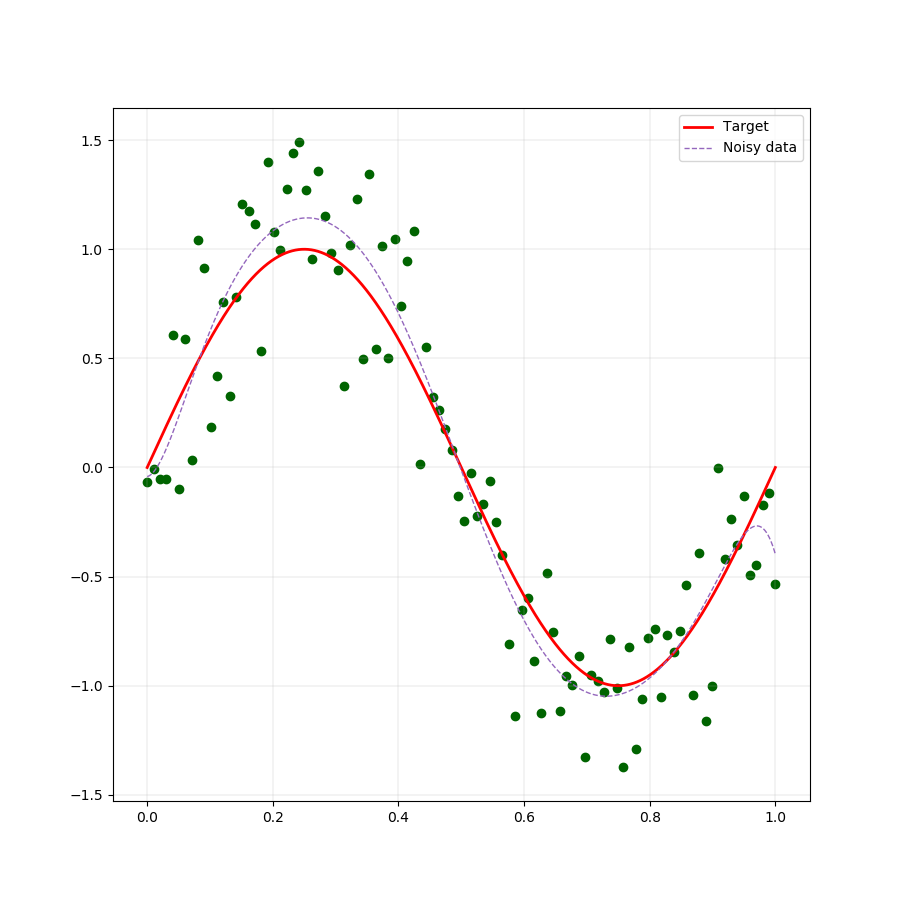

In [226]:
plt.figure(figsize=(9, 9))
plt.plot(x_plot, np.sin(x_plot * 2 * np.pi), color='r', linewidth=2.0)
plt.scatter(x_train, y_train, color='darkgreen')

plt.plot(x_plot, lg.predict(poly.fit_transform(x_plot.reshape(-1, 1))), color='C4', linewidth=1.0, linestyle='--')

plt.legend(['Target', 'Noisy data'])
plt.grid(linewidth=0.2)

Увеличеие количества данных делает модель более гибкой - она приобретает способность более качественно обобщаться на новые данные (**`generalization`**). Но что делать, если возможности увеличение датасета не существует? Можно воспользоваться различными методиками, одной из которых является **регуляризация**.

Регуляризация штрафут функцию потерь во избежание увеличения значений весов:
$$ E(\textbf{w}) = \dfrac{1}{2} \sum_{n=1}^{N} (y(x_n, \textbf{w}) - t_n)^2 + \dfrac{\lambda}{2}\|\textbf{w}^2\|, $$ 
где $ \|\textbf{w}^2\| = \textbf{w}^\intercal \textbf{w} = w_0 + w_1\,x + w_2\,x + \dots + w_M\,x^M $,

$\lambda$ - коэффициент регуляризации, который показывает важность между компонентой среднеквадратичной ошибкой и величиной штрафа. 

Такой случай регуляризации в случае линейной регрессии получил своё название **Ridge Regression** (гребневая регрессия) или **метод регуляризации Тихонова**.


# Литература

__Python__

[Python 3 для начинающих](https://pythonworld.ru/samouchitel-python)

Юрий Кашницкий [Курс языка Python и базовых алгоритмов и структур данных](https://github.com/yorko/python_intro)

[Курсы от МФТИ и Mail.ru](https://www.coursera.org/specializations/programming-in-python)

__Машинное обучение__

[ШАД: Видеолекции курса «Машинное обучение»](https://yandexdataschool.ru/edu-process/courses/machine-learning#item-1)

Christipher M. Bishop [Pattern Recognition and Machine Learning](http://users.isr.ist.utl.pt/~wurmd/Livros/school/Bishop%20-%20Pattern%20Recognition%20And%20Machine%20Learning%20-%20Springer%20%202006.pdf)

Hastie, Tibshirani, Friedman [The elements of statistical learning](https://web.stanford.edu/~hastie/Papers/ESLII.pdf)

__Глубокое обучение__

Сергей Николенко, А. Кадурин, Е. В. Архангельская [Глубокое обучение. Погружение в мир нейронных сетей](https://www.piter.com/product/glubokoe-obuchenie)

Гудфеллоу Я., Бенджио И., Курвилль А. [Глубокое обучение](https://dmkpress.com/catalog/computer/data/978-5-97060-554-7/)
